# 1. 얼굴 인식하기(extract_faces)

In [4]:
# 라이브러리 충돌을 피하기 위해 새로운 프로젝트로 만들어서 진행하시길 바랍니다.

In [ ]:
# GITHUB 살펴보기: https://github.com/serengil/deepface
# uv add tf_keras 
# uv add tensorrt --- github issue를 살펴보세요(https://github.com/serengil/deepface/issues/1339)

## 1) 기본 코드 테스트

In [1]:
from deepface import DeepFace

face_objs = DeepFace.extract_faces(
    img_path="./images/many_people.jpg",
    detector_backend="opencv",
    align=True,
    enforce_detection=False,
)

### 데이터 탐색하기

In [2]:
print(len(face_objs))

6


In [3]:
face_objs[0].keys()

dict_keys(['face', 'facial_area', 'confidence'])

In [4]:
face_objs[0]["face"].shape

(273, 273, 3)

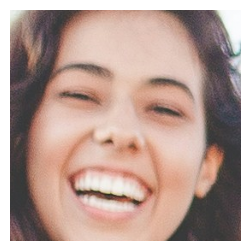

In [5]:
# uv add matplotlib
import matplotlib.pyplot as plt

idx = 2

plt.figure(figsize=(5, 3))
plt.imshow(face_objs[idx]["face"])
plt.axis("off")
plt.show()

## 2) detector_backend 바꿔보기

In [6]:
# 다른 detector_backend 넣기 : yolov12n
# uv add ultralytics
from deepface import DeepFace

face_objs = DeepFace.extract_faces(
    img_path="./images/many_people.jpg",
    detector_backend="yolov12n",
    align=True,
    enforce_detection=False,
)

26-03-24 17:02:23 - 🔗 yolov12n-face.pt will be downloaded from https://github.com/YapaLab/yolo-face/releases/download/1.0.0/yolov12n-face.pt to C:\Users\user\.deepface\weights\yolov12n-face.pt...


Downloading...
From: https://github.com/YapaLab/yolo-face/releases/download/1.0.0/yolov12n-face.pt
To: C:\Users\user\.deepface\weights\yolov12n-face.pt
100%|██████████| 5.50M/5.50M [00:00<00:00, 20.7MB/s]


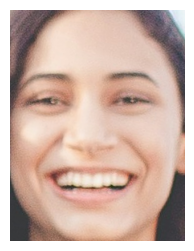

In [7]:
# uv add matplotlib
import matplotlib.pyplot as plt

idx = 4

plt.figure(figsize=(5, 3))
plt.imshow(face_objs[idx]["face"])
plt.axis("off")
plt.show()

## 3) 결과값 의미 정리

In [8]:
face_objs[0]["face"]  # 얼굴이 크롭된 사진
face_objs[0]["facial_area"]  # 박스 좌표
face_objs[0]["confidence"]  # 얼굴이 탐지된 confidence값이

0.82

# 2. 동일인인지 판별하기(verify)

In [9]:
image1_path = "./mydb/bby/bby001.jpg"
image2_path = "./mydb/bby/bby005.jpg"

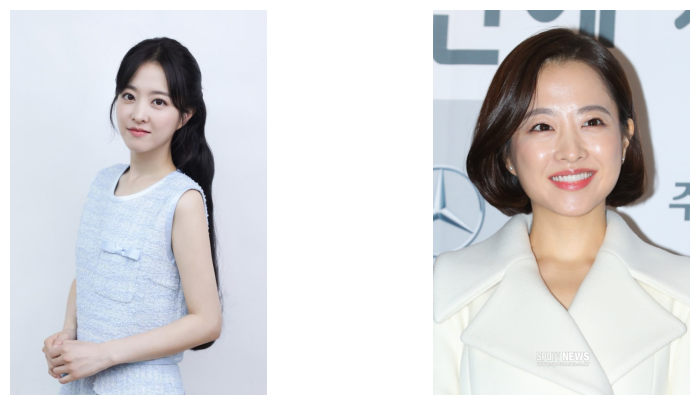

In [10]:
from PIL import Image
import matplotlib.pyplot as plt

img1 = Image.open(image1_path)
img2 = Image.open(image2_path)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img1)
ax[0].axis("off")
ax[1].imshow(img2)
ax[1].axis("off")
plt.show()

In [12]:
from deepface import DeepFace

result = DeepFace.verify(
    img1_path=image1_path,
    img2_path=image2_path,
    model_name="VGG-Face",
    enforce_detection=False,
)

result

{'verified': True,
 'distance': 0.538713,
 'threshold': 0.68,
 'confidence': 64.75,
 'model': 'VGG-Face',
 'detector_backend': 'opencv',
 'similarity_metric': 'cosine',
 'facial_areas': {'img1': {'x': 239,
   'y': 150,
   'w': 195,
   'h': 195,
   'left_eye': (368, 230),
   'right_eye': (296, 216)},
  'img2': {'x': 241,
   'y': 228,
   'w': 473,
   'h': 473,
   'left_eye': (559, 395),
   'right_eye': (379, 412)}},
 'time': 0.69}

# 3. DB에서 얼굴 찾기 (find)

In [13]:
from deepface import DeepFace

result = DeepFace.find(
    img_path="./mds_test.jpg",
    db_path="mydb",
    model_name="VGG-Face",
    detector_backend="yolov12n",
    enforce_detection=False,
    silent=False,
)

result

26-03-24 17:04:12 - Found 0 newly added image(s), 0 removed image(s), 15 replaced image(s).


Finding representations: 100%|██████████| 15/15 [00:03<00:00,  4.74it/s]

26-03-24 17:04:15 - There are now 15 representations in ds_model_vggface_detector_yolov12n_aligned_normalization_base_expand_0.pkl
26-03-24 17:04:15 - Searching ./mds_test.jpg in 15 length datastore
26-03-24 17:04:16 - find function duration 3.388417959213257 seconds


[              identity                                      hash  target_x  \
 0  mydb\mds\mds003.jpg  c4ff07be7382ea476427b0d4f2c79d2a880b6b3a       192   
 1  mydb\mds\mds002.jpg  f03cb9db7d92ec5ba6d12a302eec282f2533933a       171   
 2  mydb\mds\mds005.jpg  a3a0774271569749efa710b2193193f892a958ef       464   
 3  mydb\mds\mds004.jpg  5426b952627a704402ca3a909778f679d2018a1d       250   
 4  mydb\mds\mds001.jpg  b1184d1fac30f77161857c3ca6052adb18ae1187       354   
 
    target_y  target_w  target_h  threshold  source_x  source_y  source_w  \
 0        99       147       184       0.68       173        58       106   
 1        86       158       222       0.68       173        58       106   
 2       312       513       618       0.68       173        58       106   
 3        52       128       167       0.68       173        58       106   
 4       153       452       609       0.68       173        58       106   
 
    source_h  distance  confidence  
 0       135  0.334129 

In [14]:
print(type(result))

<class 'list'>


In [15]:
print(len(result))

1


In [16]:
print(type(result[0]))

<class 'pandas.DataFrame'>


In [17]:
import pandas as pd

result_data = pd.DataFrame(result[0])
result_data

,identity,hash,target_x,target_y,target_w,target_h,threshold,source_x,source_y,source_w,source_h,distance,confidence
0,mydb\mds\mds003.jpg,c4ff07be7382ea476427b0d4f2c79d2a880b6b3a,192,99,147,184,0.68,173,58,106,135,0.334129,88.06
1,mydb\mds\mds002.jpg,f03cb9db7d92ec5ba6d12a302eec282f2533933a,171,86,158,222,0.68,173,58,106,135,0.416209,79.26
2,mydb\mds\mds005.jpg,a3a0774271569749efa710b2193193f892a958ef,464,312,513,618,0.68,173,58,106,135,0.446248,75.73
3,mydb\mds\mds004.jpg,5426b952627a704402ca3a909778f679d2018a1d,250,52,128,167,0.68,173,58,106,135,0.484025,71.21
4,mydb\mds\mds001.jpg,b1184d1fac30f77161857c3ca6052adb18ae1187,354,153,452,609,0.68,173,58,106,135,0.526427,66.17
